In [1]:
!pip install -q "tacoreader<1.0"

import tacoreader.v1 as tacoreader

print("TACO Reader imported:", tacoreader.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 56.3 MB/s eta 0:00:0000:0100:01
TACO Reader imported: 0.6.5


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import rasterio

from skimage.metrics import structural_similarity as ssim

import tacoreader.v1 as tacoreader

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.10.0+cu128
Device: cuda


In [3]:
dataset = tacoreader.load(
    "tacofoundation:sen2naipv2-unet"
)

print("SEN2NAIPv2 loaded")

SEN2NAIPv2 loaded


In [4]:
lr_path = dataset.read(0).read(0)
hr_path = dataset.read(0).read(1)

with rasterio.open(lr_path) as src:
    lr = src.read().astype("float32")

with rasterio.open(hr_path) as src:
    hr = src.read().astype("float32")

print("LR shape:", lr.shape)
print("HR shape:", hr.shape)

print("LR range:", lr.min(), lr.max())
print("HR range:", hr.min(), hr.max())

LR shape: (4, 130, 130)
HR shape: (4, 520, 520)
LR range: 116.0 4608.0
HR range: 32.0 5032.0


In [5]:
train_pairs = []

TRAIN_SIZE = 150
BATCH_SIZE = 10

for start in range(0, TRAIN_SIZE, BATCH_SIZE):

    end = min(start + BATCH_SIZE, TRAIN_SIZE)

    print(f"Loading {start}–{end-1}...")

    for i in range(start, end):

        lr_path = dataset.read(i).read(0)
        hr_path = dataset.read(i).read(1)

        with rasterio.open(lr_path) as src:
            lr = src.read().astype("float32")

        with rasterio.open(hr_path) as src:
            hr = src.read().astype("float32")

        lr = lr / 3000.0
        hr = hr / 3000.0

        train_pairs.append(
            (lr, hr)
        )

    print(
        f"Batch complete → {len(train_pairs)}/{TRAIN_SIZE}"
    )

print("\nTraining pairs:", len(train_pairs))

Loading 0–9...
Batch complete → 10/150
Loading 10–19...
Batch complete → 20/150
Loading 20–29...
Batch complete → 30/150
Loading 30–39...
Batch complete → 40/150
Loading 40–49...
Batch complete → 50/150
Loading 50–59...
Batch complete → 60/150
Loading 60–69...
Batch complete → 70/150
Loading 70–79...
Batch complete → 80/150
Loading 80–89...
Batch complete → 90/150
Loading 90–99...
Batch complete → 100/150
Loading 100–109...
Batch complete → 110/150
Loading 110–119...
Batch complete → 120/150
Loading 120–129...
Batch complete → 130/150
Loading 130–139...
Batch complete → 140/150
Loading 140–149...
Batch complete → 150/150

Training pairs: 150


In [6]:
def make_patch(
    lr,
    hr,
    patch_size=32
):

    lr_h, lr_w = lr.shape[1:]

    y = np.random.randint(
        0,
        lr_h - patch_size + 1
    )

    x = np.random.randint(
        0,
        lr_w - patch_size + 1
    )

    lr_patch = lr[
        :,
        y:y + patch_size,
        x:x + patch_size
    ]

    hr_patch = hr[
        :,
        y * 4:y * 4 + patch_size * 4,
        x * 4:x * 4 + patch_size * 4
    ]

    return lr_patch, hr_patch

In [7]:
lr_patch, hr_patch = make_patch(
    train_pairs[0][0],
    train_pairs[0][1],
    32
)

print("LR patch:", lr_patch.shape)
print("HR patch:", hr_patch.shape)

LR patch: (4, 32, 32)
HR patch: (4, 128, 128)


In [24]:
class RCAB(nn.Module):

    def __init__(self, channels=128, reduction=8):
        super().__init__()

        self.conv1 = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.attention = nn.Sequential(
            nn.Conv2d(
                channels,
                channels // reduction,
                1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                channels // reduction,
                channels,
                1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):

        residual = x

        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)

        attention = self.avg_pool(out)
        attention = self.attention(attention)

        out = out * attention

        return residual + 0.1 * out

In [29]:
model = RCAN(
    num_blocks=20,
    channels=128
).to(device)

print("RCAN recreated")
print(
    "Parameters:",
    sum(p.numel() for p in model.parameters())
)

RCAN recreated
Parameters: 7325764


In [31]:
class RCAN(nn.Module):

    def __init__(
        self,
        num_blocks=20,
        channels=128,
        scale=4
    ):
        super().__init__()

        self.head = nn.Conv2d(
            4, channels, 3, padding=1
        )

        self.body = nn.Sequential(
            *[
                RCAB(channels)
                for _ in range(num_blocks)
            ],
            nn.Conv2d(
                channels,
                channels,
                3,
                padding=1
            )
        )

        self.up1 = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels,
            4,
            3,
            padding=1
        )

    def forward(self, x):

        shallow = self.head(x)

        body = self.body(shallow)
        body = body + shallow

        out = self.up1(body)
        out = self.up2(out)
        out = self.tail(out)

        return out

In [32]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = RCAN(
    num_blocks=20,
    channels=128
).to(device)

print("Device:", device)
print(
    "Parameters:",
    sum(p.numel() for p in model.parameters())
)

Device: cuda
Parameters: 7325764


In [33]:
class CharbonnierLoss(nn.Module):

    def __init__(
        self,
        epsilon=1e-3
    ):
        super().__init__()

        self.epsilon = epsilon

    def forward(
        self,
        pred,
        target
    ):

        diff = pred - target

        return torch.mean(
            torch.sqrt(
                diff ** 2
                + self.epsilon ** 2
            )
        )


pixel_loss = CharbonnierLoss()


def gradient_loss(
    pred,
    target
):

    pred_x = (
        pred[:, :, :, 1:]
        - pred[:, :, :, :-1]
    )

    target_x = (
        target[:, :, :, 1:]
        - target[:, :, :, :-1]
    )

    pred_y = (
        pred[:, :, 1:, :]
        - pred[:, :, :-1, :]
    )

    target_y = (
        target[:, :, 1:, :]
        - target[:, :, :-1, :]
    )

    return (
        torch.mean(
            torch.abs(
                pred_x - target_x
            )
        )
        +
        torch.mean(
            torch.abs(
                pred_y - target_y
            )
        )
    )


def spectral_angle_loss(
    pred,
    target
):

    pred = pred.permute(
        0, 2, 3, 1
    ).reshape(-1, 4)

    target = target.permute(
        0, 2, 3, 1
    ).reshape(-1, 4)

    pred = F.normalize(
        pred,
        p=2,
        dim=1,
        eps=1e-8
    )

    target = F.normalize(
        target,
        p=2,
        dim=1,
        eps=1e-8
    )

    cosine = torch.sum(
        pred * target,
        dim=1
    )

    cosine = torch.clamp(
        cosine,
        -1 + 1e-7,
        1 - 1e-7
    )

    return torch.acos(
        cosine
    ).mean()

In [38]:
charbonnier = CharbonnierLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=7e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50,
    eta_min=1e-6
)

EPOCHS = 20
PATCH_SIZE = 32
PATCHES_PER_EPOCH = 600

pixel_weight = 1.0
edge_weight = 0.10
spectral_weight = 0.08

print("Optimizer and scheduler ready")

Optimizer and scheduler ready


In [39]:
def make_patch(
    lr,
    hr,
    patch_size=32
):

    h, w = lr.shape[1:]

    y = np.random.randint(
        0,
        h - patch_size + 1
    )

    x = np.random.randint(
        0,
        w - patch_size + 1
    )

    lr_patch = lr[
        :,
        y:y + patch_size,
        x:x + patch_size
    ]

    hr_patch = hr[
        :,
        y * 4:y * 4 + patch_size * 4,
        x * 4:x * 4 + patch_size * 4
    ]

    return lr_patch, hr_patch

In [40]:
lr, hr = train_pairs[0]

lr_patch, hr_patch = make_patch(
    lr,
    hr,
    PATCH_SIZE
)

lr_tensor = torch.from_numpy(
    lr_patch
).unsqueeze(0).to(device)

hr_tensor = torch.from_numpy(
    hr_patch
).unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(lr_tensor)

print("LR        :", lr_tensor.shape)
print("Prediction:", prediction.shape)
print("HR        :", hr_tensor.shape)

LR        : torch.Size([1, 4, 32, 32])
Prediction: torch.Size([1, 4, 128, 128])
HR        : torch.Size([1, 4, 128, 128])


In [41]:
import time
from tqdm.auto import tqdm

loss_history = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0.0
    total_pixel = 0.0
    total_edge = 0.0
    total_spectral = 0.0

    start_time = time.time()

    progress = tqdm(
        range(PATCHES_PER_EPOCH),
        desc=f"Epoch {epoch + 1}/{EPOCHS}",
        unit="patch"
    )

    for step in progress:

        idx = np.random.randint(
            0,
            len(train_pairs)
        )

        lr, hr = train_pairs[idx]

        lr_patch, hr_patch = make_patch(
            lr,
            hr,
            PATCH_SIZE
        )

        lr_tensor = torch.from_numpy(
            lr_patch
        ).unsqueeze(0).to(device)

        hr_tensor = torch.from_numpy(
            hr_patch
        ).unsqueeze(0).to(device)

        optimizer.zero_grad()

        prediction = model(lr_tensor)

        loss_pixel = charbonnier(
            prediction,
            hr_tensor
        )

        loss_edge = gradient_loss(
            prediction,
            hr_tensor
        )

        loss_spectral = spectral_angle_loss(
            prediction,
            hr_tensor
        )

        loss = (
            pixel_weight * loss_pixel
            + edge_weight * loss_edge
            + spectral_weight * loss_spectral
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        total_loss += loss.item()
        total_pixel += loss_pixel.item()
        total_edge += loss_edge.item()
        total_spectral += loss_spectral.item()

        progress.set_postfix(
            loss=f"{total_loss/(step+1):.4f}",
            pixel=f"{total_pixel/(step+1):.4f}",
            edge=f"{total_edge/(step+1):.4f}",
            spectral=f"{total_spectral/(step+1):.4f}"
        )

    scheduler.step()

    avg_loss = total_loss / PATCHES_PER_EPOCH
    avg_pixel = total_pixel / PATCHES_PER_EPOCH
    avg_edge = total_edge / PATCHES_PER_EPOCH
    avg_spectral = total_spectral / PATCHES_PER_EPOCH

    loss_history.append(avg_loss)

    elapsed = time.time() - start_time

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print(f"Loss     : {avg_loss:.6f}")
    print(f"Pixel    : {avg_pixel:.6f}")
    print(f"Edge     : {avg_edge:.6f}")
    print(f"Spectral : {avg_spectral:.6f}")
    print(
        f"LR       : "
        f"{optimizer.param_groups[0]['lr']:.2e}"
    )
    print(f"Time     : {elapsed:.1f}s")
    print("-" * 55)

Epoch 1/20:   0%|          | 0/600 [00:00<?, ?patch/s]


Epoch 1/20
Loss     : 0.051893
Pixel    : 0.040961
Edge     : 0.073257
Spectral : 0.045071
LR       : 6.99e-05
Time     : 17.0s
-------------------------------------------------------


Epoch 2/20:   0%|          | 0/600 [00:00<?, ?patch/s]


Epoch 2/20
Loss     : 0.051792
Pixel    : 0.040811
Edge     : 0.075496
Spectral : 0.042898
LR       : 6.97e-05
Time     : 16.9s
-------------------------------------------------------


Epoch 3/20:   0%|          | 0/600 [00:00<?, ?patch/s]

...


Epoch 18/20
Loss     : 0.045617
Pixel    : 0.035764
Edge     : 0.072091
Spectral : 0.033048
LR       : 5.02e-05
Time     : 16.9s
-------------------------------------------------------


Epoch 19/20:   0%|          | 0/600 [00:00<?, ?patch/s]


Epoch 19/20
Loss     : 0.045664
Pixel    : 0.035875
Edge     : 0.071749
Spectral : 0.032681
LR       : 4.82e-05
Time     : 16.8s
-------------------------------------------------------


Epoch 20/20:   0%|          | 0/600 [00:00<?, ?patch/s]


Epoch 20/20
Loss     : 0.046205
Pixel    : 0.036330
Edge     : 0.072360
Spectral : 0.032984
LR       : 4.62e-05
Time     : 16.8s
-------------------------------------------------------


In [43]:
torch.save(
    model.state_dict(),
    "/kaggle/working/rcan_tuned_20epoch_weights.pth"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch": 20,
        "loss_history": loss_history,
        "config": {
            "num_blocks": 20,
            "channels": 128,
            "scale": 4,
            "lr": 7e-5,
            "weight_decay": 1e-4,
            "patch_size": 32,
            "pixel_weight": 1.0,
            "edge_weight": 0.10,
            "spectral_weight": 0.08
        }
    },
    "/kaggle/working/rcan_tuned_20epoch_checkpoint.pth"
)

print("Model and checkpoint saved.")

Model and checkpoint saved.


In [46]:
# =========================
# LOAD TEST DATA
# =========================

TEST_START = 150
TEST_SIZE = 10

test_pairs = []

for i in range(
    TEST_START,
    TEST_START + TEST_SIZE
):

    print(f"Loading test image {i}...")

    lr_path = dataset.read(i).read(0)
    hr_path = dataset.read(i).read(1)

    with rasterio.open(lr_path) as src:
        lr = src.read().astype("float32")

    with rasterio.open(hr_path) as src:
        hr = src.read().astype("float32")

    lr = lr / 3000.0
    hr = hr / 3000.0

    test_pairs.append(
        (lr, hr)
    )

print(
    "\nTest pairs:",
    len(test_pairs)
)

print(
    "LR shape:",
    test_pairs[0][0].shape
)

print(
    "HR shape:",
    test_pairs[0][1].shape
)


Loading test image 150...
Loading test image 151...
Loading test image 152...
Loading test image 153...
Loading test image 154...
Loading test image 155...
Loading test image 156...
Loading test image 157...
Loading test image 158...
Loading test image 159...

Test pairs: 10
LR shape: (4, 130, 130)
HR shape: (4, 520, 520)


In [57]:
predictions_raw = []
targets = []

model.eval()

with torch.no_grad():

    for i, (lr, hr) in enumerate(test_pairs):

        lr_tensor = torch.from_numpy(
            lr
        ).unsqueeze(0).to(device)

        prediction = model(
            lr_tensor
        )

        prediction = (
            prediction
            .squeeze(0)
            .cpu()
            .numpy()
        )

        predictions_raw.append(
            prediction
        )

        targets.append(
            hr
        )

        print(
            f"Test image {TEST_START + i}: "
            f"{prediction.shape} | "
            f"range: "
            f"{prediction.min():.3f} → "
            f"{prediction.max():.3f}"
        )

predictions_raw = np.array(
    predictions_raw
)

targets = np.array(
    targets
)

print("\nPredictions:", predictions_raw.shape)
print("Targets    :", targets.shape)

Test image 150: (4, 520, 520) | range: 0.052 → 2.330
Test image 151: (4, 520, 520) | range: 0.040 → 2.446
Test image 152: (4, 520, 520) | range: 0.056 → 3.011
Test image 153: (4, 520, 520) | range: 0.016 → 2.877
Test image 154: (4, 520, 520) | range: 0.075 → 1.734
Test image 155: (4, 520, 520) | range: 0.021 → 2.904
Test image 156: (4, 520, 520) | range: 0.084 → 1.935
Test image 157: (4, 520, 520) | range: 0.053 → 2.445
Test image 158: (4, 520, 520) | range: 0.002 → 2.942
Test image 159: (4, 520, 520) | range: 0.046 → 2.351

Predictions: (10, 4, 520, 520)
Targets    : (10, 4, 520, 520)


In [60]:
predictions = predictions_raw

mse = np.mean(
    (predictions - targets) ** 2
)

rmse = np.sqrt(mse)

psnr = 10 * np.log10(
    1.0 / (mse + 1e-10)
)

ssim_scores = []

for i in range(
    len(targets)
):

    score = ssim(
        targets[i].transpose(1, 2, 0),
        predictions[i].transpose(1, 2, 0),
        channel_axis=2,
        data_range=1
    )

    ssim_scores.append(score)

mean_ssim = np.mean(
    ssim_scores
)

print(
    "========== TUNED RCAN RESULT =========="
)

print(
    f"RMSE : {rmse:.5f}"
)

print(
    f"PSNR : {psnr:.3f} dB"
)

print(
    f"SSIM : {mean_ssim:.4f}"
)

========== TUNED RCAN RESULT ==========
RMSE : 0.06545
PSNR : 23.682 dB
SSIM : 0.7061


In [58]:
mse = np.mean(
    (predictions - targets) ** 2
)

rmse = np.sqrt(mse)

psnr = 10 * np.log10(
    1.0 / (mse + 1e-10)
)

ssim_scores = []

for i in range(
    len(targets)
):

    score = ssim(
        targets[i].transpose(1, 2, 0),
        predictions[i].transpose(1, 2, 0),
        channel_axis=2,
        data_range=1
    )

    ssim_scores.append(score)

mean_ssim = np.mean(
    ssim_scores
)

print(
    "========== TUNED RCAN RESULT =========="
)

print(
    f"RMSE : {rmse:.5f}"
)

print(
    f"PSNR : {psnr:.3f} dB"
)

print(
    f"SSIM : {mean_ssim:.4f}"
)

========== TUNED RCAN RESULT ==========
RMSE : 0.10432
PSNR : 19.633 dB
SSIM : 0.6565


In [59]:
 import pandas as pd
comparison = pd.DataFrame([

    {
        "Model": "RCAN Baseline",
        "RMSE": 0.05746,
        "PSNR": 24.813,
        "SSIM": 0.6793
    },

    {
        "Model": "Improved RCAN",
        "RMSE": 0.05542,
        "PSNR": 25.127,
        "SSIM": 0.6908
    },

    {
        "Model": "RCAN + HAT",
        "RMSE": 0.06555,
        "PSNR": 23.669,
        "SSIM": 0.7048
    },

    {
        "Model": "RCAN + HAT v2",
        "RMSE": 0.06546,
        "PSNR": 23.680,
        "SSIM": 0.7061
    },

    {
        "Model": "RCAN + SwinIR",
        "RMSE": 0.06577,
        "PSNR": 23.639,
        "SSIM": np.nan
    },

    {
        "Model": "SwinIR Only",
        "RMSE": 0.067206,
        "PSNR": 23.452,
        "SSIM": 0.6958
    },

    {
        "Model": "Tuned RCAN",
        "RMSE": rmse,
        "PSNR": psnr,
        "SSIM": mean_ssim
    }
])

comparison.style.format({
    "RMSE": "{:.5f}",
    "PSNR": "{:.3f}",
    "SSIM": "{:.4f}"
})

,Model,RMSE,PSNR,SSIM
0,RCAN Baseline,0.05746,24.813,0.6793
1,Improved RCAN,0.05542,25.127,0.6908
2,RCAN + HAT,0.06555,23.669,0.7048
3,RCAN + HAT v2,0.06546,23.680,0.7061
4,RCAN + SwinIR,0.06577,23.639,nan
5,SwinIR Only,0.06721,23.452,0.6958
6,Tuned RCAN,0.10432,19.633,0.6565


In [51]:
print(
    "========== WINNERS =========="
)

best_rmse = comparison.loc[
    comparison["RMSE"].idxmin()
]

best_psnr = comparison.loc[
    comparison["PSNR"].idxmax()
]

best_ssim = comparison.loc[
    comparison["SSIM"].idxmax()
]

print(
    "\nBest RMSE:"
)

print(best_rmse)

print(
    "\nBest PSNR:"
)

print(best_psnr)

print(
    "\nBest SSIM:"
)

print(best_ssim)

========== WINNERS ==========

Best RMSE:
Model    Improved RCAN
RMSE           0.05542
PSNR            25.127
SSIM            0.6908
Name: 1, dtype: object

Best PSNR:
Model    Improved RCAN
RMSE           0.05542
PSNR            25.127
SSIM            0.6908
Name: 1, dtype: object

Best SSIM:
Model    RCAN + HAT v2
RMSE           0.06546
PSNR             23.68
SSIM            0.7061
Name: 3, dtype: object


In [52]:
def stretch_rgb(img):

    rgb = img[:3].transpose(
        1, 2, 0
    )

    output = np.zeros_like(rgb)

    for c in range(3):

        low = np.percentile(
            rgb[:, :, c],
            2
        )

        high = np.percentile(
            rgb[:, :, c],
            98
        )

        output[:, :, c] = np.clip(
            (rgb[:, :, c] - low)
            / (high - low + 1e-8),
            0,
            1
        )

    return output

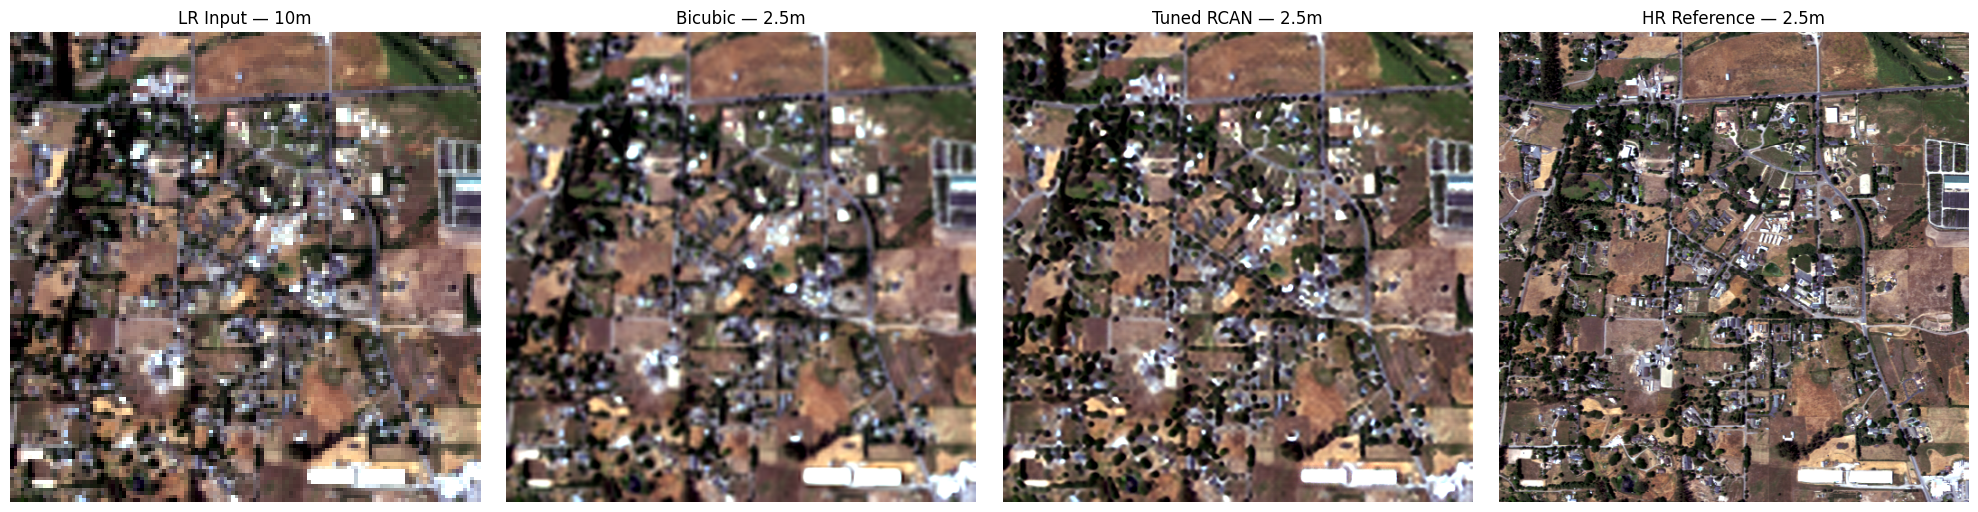

In [53]:
i = 0

lr = test_pairs[i][0]
hr = targets[i]
sr = predictions[i]

lr_tensor = torch.tensor(
    lr,
    dtype=torch.float32
).unsqueeze(0)

bicubic = F.interpolate(
    lr_tensor,
    size=hr.shape[-2:],
    mode="bicubic",
    align_corners=False
)[0].numpy()

plt.figure(
    figsize=(20, 5)
)

plt.subplot(1, 4, 1)

plt.imshow(
    stretch_rgb(lr)
)

plt.title(
    "LR Input — 10m"
)

plt.axis("off")


plt.subplot(1, 4, 2)

plt.imshow(
    stretch_rgb(bicubic)
)

plt.title(
    "Bicubic — 2.5m"
)

plt.axis("off")


plt.subplot(1, 4, 3)

plt.imshow(
    stretch_rgb(sr)
)

plt.title(
    "Tuned RCAN — 2.5m"
)

plt.axis("off")


plt.subplot(1, 4, 4)

plt.imshow(
    stretch_rgb(hr)
)

plt.title(
    "HR Reference — 2.5m"
)

plt.axis("off")


plt.tight_layout()
plt.show()

In [54]:
print("Targets:")
print("Min :", targets.min())
print("Max :", targets.max())
print("Mean:", targets.mean())

print("\nPredictions:")
print("Min :", predictions.min())
print("Max :", predictions.max())
print("Mean:", predictions.mean())

Targets:
Min : 0.036
Max : 3.836
Mean: 0.50211537

Predictions:
Min : 0.0015905835
Max : 1.0
Mean: 0.4745812


In [55]:
print(
    "Target values > 1:",
    np.mean(targets > 1.0) * 100,
    "%"
)

print(
    "Prediction values > 1:",
    np.mean(predictions > 1.0) * 100,
    "%"
)

Target values > 1: 13.262204142011836 %
Prediction values > 1: 0.0 %
